<a href="https://colab.research.google.com/github/ramsaher/DEVF_Master_Ciencias_de_Datos/blob/main/6_Mayo_Hands_Aprendizaje_Sup_On_KNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors

En este script de Python veremos como implementar en código todo lo que vimos ya conceptualmente. Python tiene muchas funciones que nos facilitan la vida, y por eso es importante saber qué es lo que está haciendo la computadora cuando hacemos código, y no sólo escribir código a lo tonto.

### Paso 1: Importamos las principales bibliotecas que vamos a utilizar en la sesión.
Abrá otras que importareamos después según vayamos requiriendo las funciones

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Paso 2: descargo e importo la base de datos

In [ ]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/d546eaee765268bf2f487608c537c05e22e4b221/iris.csv'

In [ ]:
iris = pd.read_csv(url)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Imaginémonos que nuestro KNN va a clasificar con base en dos atributos nada más. ¿Qué vemos en la gráfica? Los azules todo bien pero, ¿es clara la "diferencia" entre naranjas y verdes? ¿Cómo lo podríamos solucionar?


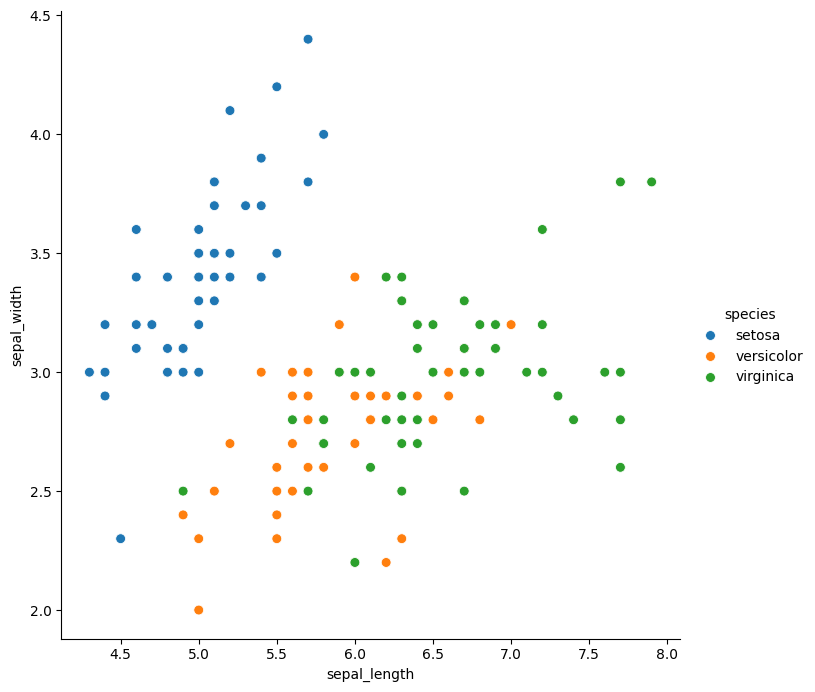

In [ ]:
sns.pairplot(x_vars='sepal_length', y_vars='sepal_width', data=iris, plot_kws={'s': 50}, height=7, hue='species')

### Paso 3: Separo mi base en atributos (variables independientes, si quieren verlo así) y etiquetas (variable dependiente)

In [ ]:
# Set de características
x = iris.iloc[:, :4].values # 0, 1, 2, 3
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
# Columna de respuestas
y = iris.iloc[:, 4].values
y

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

#¿Knearest ?

![knearest](https://miro.medium.com/max/1022/1*AuXDgGrr0wbCoF6KDXXSZQ.jpeg)


El algoritmo k-nearest neighbors (KNN) es un algoritmo de aprendizaje automático simple y supervisado que puede utilizarse para resolver tanto problemas de clasificación como de regresión. Es fácil de implementar y entender, pero tiene el gran inconveniente de volverse significativamente lento a medida que crece el tamaño de los datos en uso.
KNN funciona encontrando las distancias entre una consulta y todos los ejemplos de los datos, seleccionando el número especificado de ejemplos (K) más cercanos a la consulta, y luego vota por la etiqueta más frecuente (en el caso de la clasificación) o promedia las etiquetas (en el caso de la regresión).
En el caso de la clasificación y la regresión, la elección de la K correcta para nuestros datos se realiza probando varias K y eligiendo la que mejor funciona.


En la clasificación k-NN, el resultado es la pertenencia a una clase. Un objeto se clasifica mediante un voto plural de sus vecinos, asignando el objeto a la clase más común entre sus k vecinos más cercanos (k es un número entero positivo, normalmente pequeño). Si k = 1, el objeto se asigna simplemente a la clase de ese único vecino más cercano.

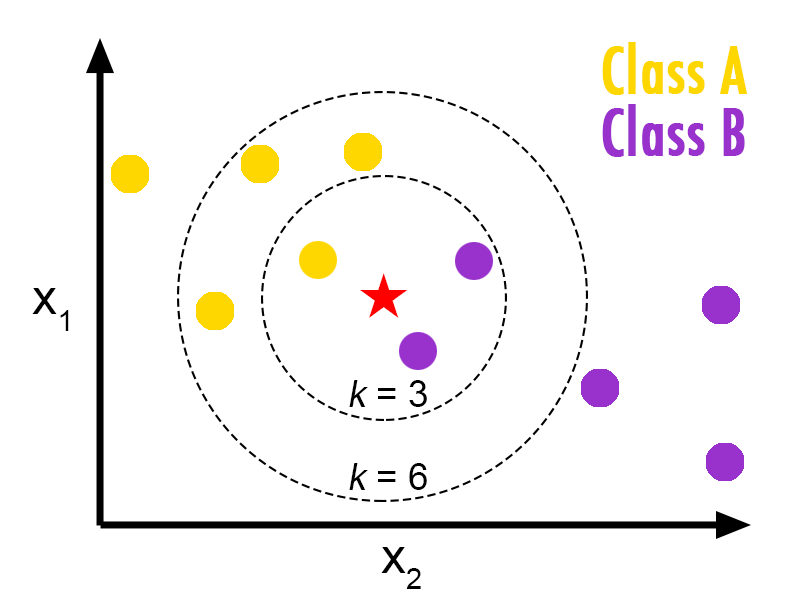

![tomato](https://jiayiwangjw.github.io/img/KNN/tomato.png)

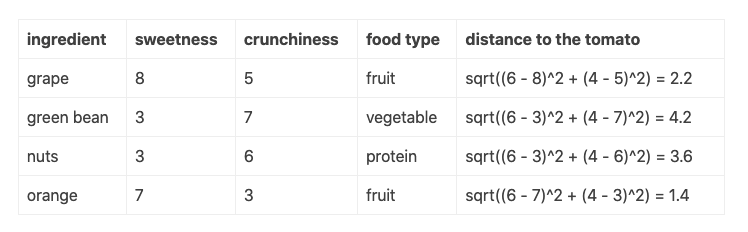

### Paso 4: Vamos a dividir nuestra base en una base de entrenamiento y otra de prueba. Dejemos 80% para que el KNN memorice, y 20% para ver qué tan bien "aprendió" a clasificar

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [ ]:
# Conjunto de entrenamiento
len(x_train)

120

In [ ]:
# Conjunto de pruebas
len(x_test)

30

En teoría, una buena K para empezar a explorar es la raíz cuadrada del número de observaciones de mi base de entrenamiento. En este caso es la raíz de 120, es decir, 11 aproximadamente.

In [ ]:
import math
math.sqrt(len(x_train))

10.954451150103322

![good_k](https://jiayiwangjw.github.io/img/KNN/how%20much%20is%20K.png)

### Paso 5: Normalizo mis datos para que tengan una escala común

Primero importo la función que me permite normalizar facilmente, y luego le digo que calcule media y desviación que va a usar luego para normalizar (en la parte del fit).

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(x_train) # Construimos las equivalencias
# 7.3 -> 1, 5.0 -> 0, 6.1 -> 0.5

MinMaxScaler()

Ahora sí, re-escalo mis variables

In [ ]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[ 0.22857143,  0.78947368,  0.08474576,  0.04166667],
       [ 0.51428571,  0.47368421,  0.55932203,  0.5       ],
       [ 0.57142857,  0.63157895,  0.59322034,  0.58333333],
       [ 0.22857143,  1.10526316,  0.08474576,  0.        ],
       [ 0.31428571,  0.26315789,  0.50847458,  0.5       ],
       [ 0.37142857,  0.42105263,  0.52542373,  0.5       ],
       [ 0.4       ,  0.36842105,  0.49152542,  0.45833333],
       [ 0.57142857,  0.42105263,  0.77966102,  0.875     ],
       [ 0.6       ,  0.52631579,  0.76271186,  0.70833333],
       [ 0.51428571,  0.42105263,  0.6440678 ,  0.70833333],
       [ 0.31428571,  0.78947368,  0.05084746,  0.04166667],
       [ 0.34285714,  0.52631579,  0.59322034,  0.58333333],
       [ 0.31428571,  1.15789474,  0.06779661,  0.04166667],
       [ 0.2       ,  0.78947368,  0.06779661,  0.04166667],
       [ 0.54285714,  0.68421053,  0.84745763,  1.        ],
       [ 0.45714286,  0.73684211,  0.59322034,  0.625     ],
       [ 0.8       ,  0.

In [ ]:
x_train.min(), x_train.max()

(0.0, 1.0)

### Paso 6: Importo mi clasificador y le digo que memorice los datos de entrenamiento

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=11)
classifier.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=11)

### Paso 7: Hago la predicción con mis atributos del set de prueba

In [ ]:
y_pred = classifier.predict(x_test)
y_pred

array(['setosa', 'versicolor', 'versicolor', 'setosa', 'versicolor',
       'versicolor', 'versicolor', 'virginica', 'virginica', 'virginica',
       'setosa', 'versicolor', 'setosa', 'setosa', 'virginica',
       'versicolor', 'virginica', 'virginica', 'setosa', 'virginica',
       'versicolor', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa'], dtype=object)

### Paso 8: revisamos qué tan bien lo hicimos

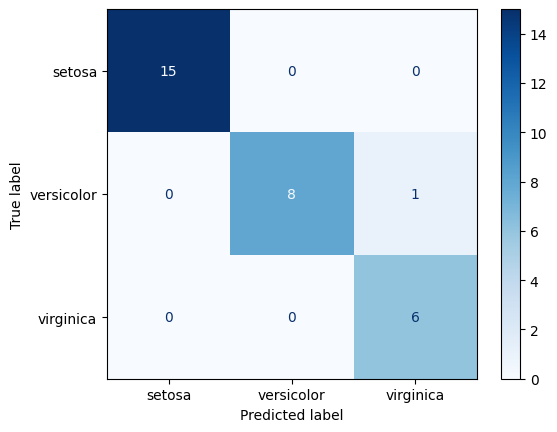

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['setosa', 'versicolor', 'virginica']
normalize = None
ConfusionMatrixDisplay.from_estimator(
        classifier,
        x_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.89      0.94         9
   virginica       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.96      0.95        30
weighted avg       0.97      0.97      0.97        30



**EXTRA: podemos ver con nuestro set de prueba el número de errores promedio que tendríamos con distintas K's

In [ ]:
error = []

for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test))

error

[0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.06666666666666667,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.06666666666666667,
 0.06666666666666667,
 0.13333333333333333]

(0.0, 0.2)

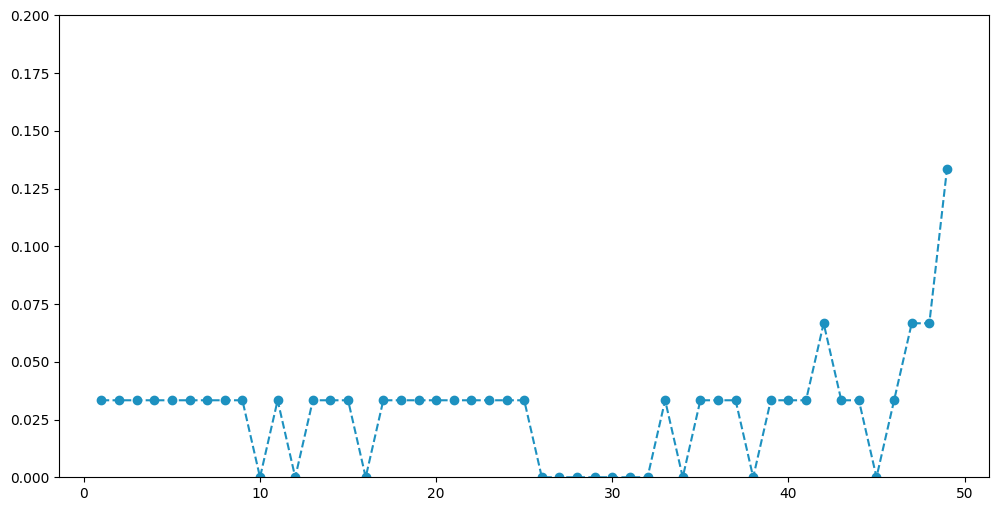

In [ ]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 50), error, color = '#1d91c0', linestyle = 'dashed', marker = 'o')
plt.ylim(0, 0.2)

# Challenge: Cancer data

## Objetivo:
Detectar los tumores malignos y beningnos mediante el dataset que recaba múltiples características

1. Aplicar el algoritmo de KNN a ([data.csv](https://drive.google.com/file/d/18f1srPV-Bwp_JH_t4_eujW1MgY1H3rZv/view?usp=drive_link))
2. Evaluar el rendimiento del modelo

# 🤖 K-Nearest Neighbors (KNN)
## Análisis de Datos con Machine Learning

---

### ¿Qué es KNN? (Para principiantes)

Imaginemos que somos nuevos en una ciudad y queremos saber si un vecindario es seguro.
Lo que haríamos naturalmente es **preguntar a tus vecinos más cercanos** y decidir
basándote en su opinión.

**KNN hace exactamente eso con los datos:**
- Toma un dato nuevo (el tumor, el vino)
- Busca los **K vecinos más parecidos** en los datos que ya conoce
- Y decide según la **mayoría** de esos vecinos

Si K=5 y 4 de 5 vecinos dicen "benigno" → el modelo dice "benigno".

---

###  Casos que resolveremos:
1. **Caso 1:** Detectar tumores malignos vs benignos (Datos médicos de cáncer)
2. **Caso 2:** Clasificar calidad del vino (6 niveles de calidad)

#  BLOQUE 1 — Instalación e Importación de Librerías

Antes de cocinar, necesitamos los ingredientes.
Aquí instalamos e importamos todas las herramientas que vamos a usar.

In [ ]:
# Instalamos la librería para descargar el dataset de vino
# ucimlrepo = repositorio oficial de datasets de la Universidad de California

!pip install ucimlrepo --quiet

print("Instalación completada")

Instalación completada


In [ ]:
# IMPORTAMOS TODAS LAS HERRAMIENTAS QUE USAREMOS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de scikit-learn (la librería de Machine Learning más usada)
# KNeighborsClassifier → el modelo KNN que vamos a usar

from sklearn.neighbors import KNeighborsClassifier

# train_test_split → para dividir datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split, cross_val_score

# StandardScaler → para normalizar los datos (muy importante en KNN)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Métricas para evaluar qué tan bueno es el modelo

from sklearn.metrics import (
    accuracy_score,        # Exactitud general
    precision_score,       # Precisión (de los que predijo positivo, ¿cuántos lo eran?)
    recall_score,          # Recuperación (de todos los positivos reales, ¿cuántos encontró?)
    f1_score,              # Promedio entre precisión y recuperación
    confusion_matrix,      # Matriz de confusión (tabla de aciertos y errores)
    classification_report  # Reporte completo de métricas
)

# Para descargar el dataset de vino

from ucimlrepo import fetch_ucirepo

# Configuración de estilo para las gráficas

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Para ignorar advertencias que no son errores

import warnings
warnings.filterwarnings('ignore')

print("Todas las librerías importadas correctamente")

Todas las librerías importadas correctamente


# CASO 1: CLASIFICACIÓN DE TUMORES CON KNN
## Dataset: Datos de Cáncer de Mama (Wisconsin)

**¿Cuál es el problema?**
Un médico toma medidas de un tumor (tamaño, textura, forma, etc.).
Con esos datos, ¿podemos ayudar a predecir si el tumor es **maligno (M)** o **benigno (B)**?

- **Maligno (M)**: Canceroso → requiere tratamiento urgente
- **Benigno (B)**: No canceroso → menos peligroso

**¿Por qué importan las métricas en medicina?**
Aquí los errores tienen consecuencias muy distintas:
- Decir "benigno" cuando es maligno → El paciente no recibe tratamiento
- Decir "maligno" cuando es benigno → El paciente recibe estudios innecesarios

Por eso usaremos métricas especiales que van más allá del simple porcentaje de aciertos.

##  BLOQUE A — Carga y Exploración del Dataset de Cáncer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Cargamos el dataset desde Drive

ruta_colab = '/content/MyDrive/'
df_cancer = pd.read_csv('/content/drive/MyDrive/data_cancer.csv')
print("Dataset cargado exitosamente")
print(f" El dataset tiene {df_cancer.shape[0]} filas y {df_cancer.shape[1]} columnas")



Dataset cargado exitosamente
 El dataset tiene 569 filas y 33 columnas


In [ ]:
# EXPLORACIÓN INICIAL

print("="*55)
print(" EXPLORACIÓN DEL DATASET DE CÁNCER")
print("="*55)

# ¿Cuántas filas y columnas tiene?

filas, columnas = df_cancer.shape
print(f"\n Dimensiones del dataset:")
print(f"   • Filas (pacientes):    {filas}")
print(f"   • Columnas (variables): {columnas}")

# ¿Cuántos casos hay de cada tipo?

print(f"\n Distribución de diagnósticos:")
conteo = df_cancer['diagnosis'].value_counts()
for diag, total in conteo.items():
    tipo = 'Maligno (canceroso)' if diag == 'M' else 'Benigno (no canceroso)'
    print(f"   • {diag} — {tipo}: {total} casos ({total/filas*100:.1f}%)")

# Vemos las primeras filas para entender la estructura

print("\n Primeras 5 filas del dataset:")
df_cancer.head(10)

 EXPLORACIÓN DEL DATASET DE CÁNCER

 Dimensiones del dataset:
   • Filas (pacientes):    569
   • Columnas (variables): 31

 Distribución de diagnósticos:
   • B — Benigno (no canceroso): 357 casos (62.7%)
   • M — Maligno (canceroso): 212 casos (37.3%)

 Primeras 5 filas del dataset:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [ ]:
# Información general del dataset
print("\n Información del dataset:")
print(df_cancer.info())

# Verificamos valores nulos (importante para limpieza)
print("\n Valores nulos por columna:")
print(df_cancer.isnull().sum())

# Ver la distribución de la variable objetivo (diagnóstico)
print("\n Distribución de la variable 'diagnosis':")
print(df_cancer['diagnosis'].value_counts())


 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14 

In [ ]:
# Revisar si hay valores nulos o columnas innecesarias

print(" Verificando valores nulos por columna:")
nulos = df_cancer.isnull().sum()
columnas_con_nulos = nulos[nulos > 0]

if len(columnas_con_nulos) > 0:
    print(columnas_con_nulos)
else:
    print("    No hay valores nulos (¡dataset limpio!)")

# La columna 'Unnamed: 32' aparece vacía en muchos CSVs de este dataset
# La eliminamos porque no aporta información

if 'Unnamed: 32' in df_cancer.columns:
    df_cancer = df_cancer.drop(columns=['Unnamed: 32'])
    print("\n  Columna 'Unnamed: 32' eliminada (estaba vacía)")

# La columna 'id' es el identificador del paciente, no nos sirve para predecir

df_cancer = df_cancer.drop(columns=['id'])
print("  Columna 'id' eliminada (no aporta al modelo)")

print(f"\n Dataset final: {df_cancer.shape[0]} filas, {df_cancer.shape[1]} columnas")

 Verificando valores nulos por columna:
Unnamed: 32    569
dtype: int64

  Columna 'Unnamed: 32' eliminada (estaba vacía)
  Columna 'id' eliminada (no aporta al modelo)

 Dataset final: 569 filas, 31 columnas


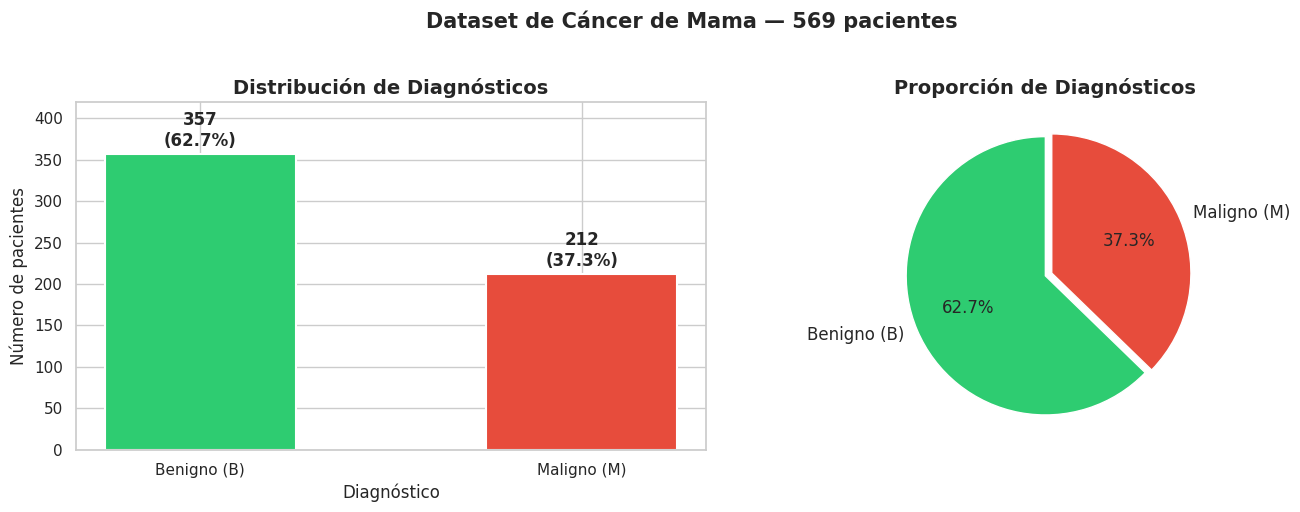


 Observación: El dataset está moderadamente balanceado.
   62.7% benignos y 37.3% malignos. Podemos trabajar con esto.


In [ ]:
# VISUALIZACIÓN 1: Distribución de diagnósticos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de barras
colores = {'M': '#e74c3c', 'B': '#2ecc71'}  # Rojo para maligno, verde para benigno
conteo = df_cancer['diagnosis'].value_counts()
bars = axes[0].bar(conteo.index, conteo.values,
                   color=[colores[x] for x in conteo.index],
                   edgecolor='white', linewidth=1.5, width=0.5)

# Añadimos etiquetas encima de cada barra
for bar, valor in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{valor}\n({valor/len(df_cancer)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[0].set_title('Distribución de Diagnósticos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Número de pacientes')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Benigno (B)', 'Maligno (M)'])
axes[0].set_ylim(0, 420)

# Gráfica de pastel
axes[1].pie(conteo.values,
            labels=['Benigno (B)', 'Maligno (M)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Proporción de Diagnósticos', fontsize=14, fontweight='bold')

plt.suptitle('Dataset de Cáncer de Mama — 569 pacientes', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cancer_distribucion.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n Observación: El dataset está moderadamente balanceado.")
print("   62.7% benignos y 37.3% malignos. Podemos trabajar con esto.")

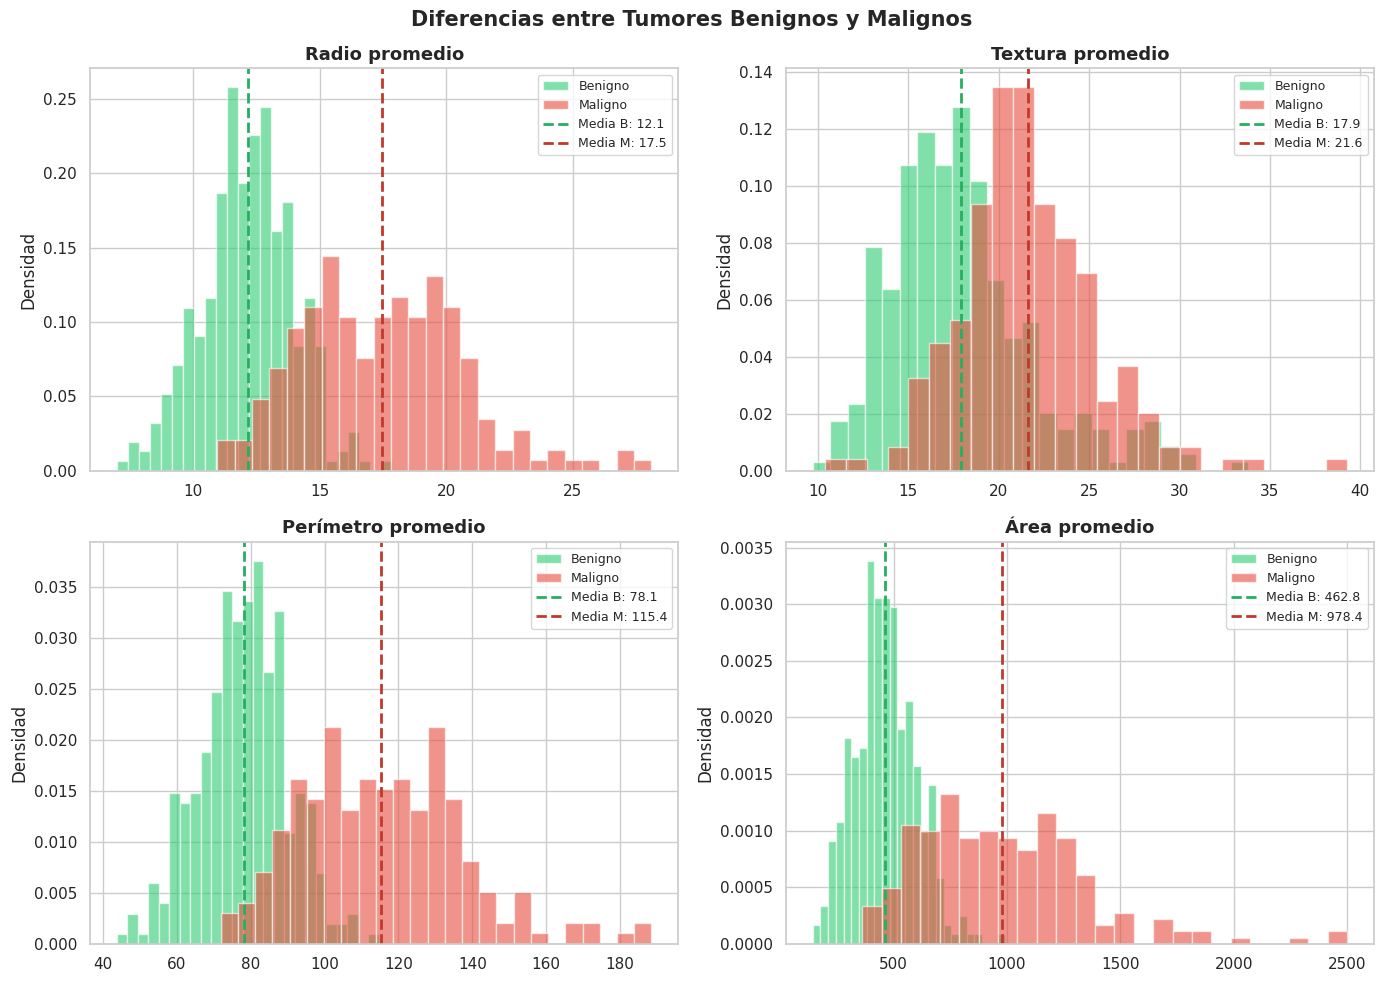


 Observación: Los tumores malignos tienden a ser más grandes
   (mayor radio, perímetro y área). Esto ayudará al modelo a distinguirlos.


In [ ]:
# VISUALIZACIÓN 2: Comparar algunas variables entre M y B

# ¿Qué tan diferentes son los tumores malignos vs benignos?

# Seleccionamos 4 características importantes para visualizar

features_visualizar = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
nombres_bonitos = ['Radio promedio', 'Textura promedio', 'Perímetro promedio', 'Área promedio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Convertimos la matriz 2x2 en una lista de 4

for i, (feature, nombre) in enumerate(zip(features_visualizar, nombres_bonitos)):

    # Separamos los datos por diagnóstico

    benignos = df_cancer[df_cancer['diagnosis'] == 'B'][feature]
    malignos = df_cancer[df_cancer['diagnosis'] == 'M'][feature]

    # Histograma superpuesto

    axes[i].hist(benignos, bins=25, alpha=0.6, color='#2ecc71', label='Benigno', density=True)
    axes[i].hist(malignos, bins=25, alpha=0.6, color='#e74c3c', label='Maligno', density=True)

    # Líneas verticales para el promedio de cada grupo

    axes[i].axvline(benignos.mean(), color='#27ae60', linestyle='--', linewidth=2,
                    label=f'Media B: {benignos.mean():.1f}')
    axes[i].axvline(malignos.mean(), color='#c0392b', linestyle='--', linewidth=2,
                    label=f'Media M: {malignos.mean():.1f}')

    axes[i].set_title(nombre, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=9)

plt.suptitle('Diferencias entre Tumores Benignos y Malignos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('cancer_comparacion.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n Observación: Los tumores malignos tienden a ser más grandes")
print("   (mayor radio, perímetro y área). Esto ayudará al modelo a distinguirlos.")

##⚙️ BLOQUE B — Preparación de los Datos para el Modelo

Antes de entrenar el modelo, necesitamos:

- **Separar X e y →** Las características (inputs) y la etiqueta (lo que queremos predecir)
- **Convertir la etiqueta →** El modelo necesita números, sin letras (B=0, M=1)
- **Normalizar →** KNN es muy sensato a las escalas. Si una variable va de 0-1000 y otra de 0-1, la grande domina injustamente
- **Dividir en entrenamiento y prueba →** como estudiar con unos apuntes y ser evaluado con otros

In [ ]:
# Separar variables de entrada (X) y objetivo (y)

# X = todas las columnas EXCEPTO 'diagnosis' (las características del tumor)

X_cancer = df_cancer.drop(columns=['diagnosis'])

# y = solo la columna 'diagnosis' (lo que queremos predecir)

y_cancer = df_cancer['diagnosis']

print(" Dimensiones:")
print(f"   X (características): {X_cancer.shape} → {X_cancer.shape[1]} variables por paciente")
print(f"   y (objetivo):        {y_cancer.shape} → 1 etiqueta por paciente")
print(f"\n  Etiquetas únicas en y: {y_cancer.unique()}")


# PASO 4: Convertir etiquetas de texto a números
# B (Benigno)  → 0
# M (Maligno)  → 1


# LabelEncoder convierte automáticamente: ordena alfabéticamente → B=0, M=1
le = LabelEncoder()
y_cancer_encoded = le.fit_transform(y_cancer)

print(f"\n Conversión de etiquetas:")
print(f"   B (Benigno)  → {le.transform(['B'])[0]}")
print(f"   M (Maligno)  → {le.transform(['M'])[0]}")
print(f"\n   Primeros 5 valores originales: {list(y_cancer[:5])}")
print(f"   Primeros 5 valores codificados: {list(y_cancer_encoded[:5])}")

 Dimensiones:
   X (características): (569, 30) → 30 variables por paciente
   y (objetivo):        (569,) → 1 etiqueta por paciente

  Etiquetas únicas en y: ['M' 'B']

 Conversión de etiquetas:
   B (Benigno)  → 0
   M (Maligno)  → 1

   Primeros 5 valores originales: ['M', 'M', 'M', 'M', 'M']
   Primeros 5 valores codificados: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


In [ ]:
# Dividir en datos de ENTRENAMIENTO y PRUEBA

# Analogía: Es como estudiar para un examen
# - Entrenamiento (80%) = apuntes con los que estudias
# - Prueba (20%)        = el examen final con preguntas nuevas
#
# random_state=42 → para que siempre salga la misma división
# stratify=y → asegura que ambos conjuntos tengan proporción similar de M y B


X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer,           # Características
    y_cancer_encoded,   # Etiquetas codificadas
    test_size=0.20,     # 20% para prueba
    random_state=42,    # Semilla para reproducibilidad
    stratify=y_cancer_encoded  # Mantiene proporciones de M y B
)

print("  División de datos:")
print(f"   Entrenamiento: {X_train_c.shape[0]} pacientes ({X_train_c.shape[0]/569*100:.0f}%)")
print(f"   Prueba:        {X_test_c.shape[0]} pacientes ({X_test_c.shape[0]/569*100:.0f}%)")
print(f"\n   Malignos en entrenamiento: {y_train_c.sum()}")
print(f"   Malignos en prueba:        {y_test_c.sum()}")

  División de datos:
   Entrenamiento: 455 pacientes (80%)
   Prueba:        114 pacientes (20%)

   Malignos en entrenamiento: 170
   Malignos en prueba:        42


#¿QUÉ ES UN SCALER?

Un "scaler" es una herramienta que transforma tus datos para que todas las
variables tengan la misma escala (el mismo rango de valores).

 Imagina que tienes:

 - Edad: 0 a 100 años
 - Altura: 1.5 a 2.0 metros
 - Ingresos: 0 a 1,000,000 euros

Sin escalar, los ingresos dominarían las distancias solo por tener números
más grandes. El scaler evita esto.

# NORMALIZAR DATOS DE ENTRENAMIENTO (fit_transform)

 fit_transform hace dos cosas IMPORTANTES:

 1. FIT (aprender):
    - Calcula la MEDIA de cada columna (variable)
    - Calcula la DESVIACIÓN ESTÁNDAR de cada columna
    - Guarda estos valores DENTRO del scaler (scaler_c)
    - Ejemplo: aprende que 'radius_mean' tiene media = 14.5 y desviación = 3.5

 2. TRANSFORM (aplicar):
    - Usa la fórmula: (valor_original - media) / desviación
    - Convierte CADA número a su versión normalizada
    - Ejemplo: 14.5 se convierte en 0, 18.0 se convierte en +1, etc.

 El resultado: X_train_c_scaled son los datos NORMALIZADOS
- X_train_c_scaled = scaler_c.fit_transform(X_train_c))

 # NORMALIZAR DATOS DE PRUEBA (solo transform)

 IMPORTANTE: Aquí SOLO usamos transform, NO fit_transform

 ¿Por qué?
 - Los datos de prueba deben ser transformados usando las MISMAS medias
   y desviaciones que aprendiste con los datos de entrenamiento

 - Si usaras fit_transform aquí, el scaler aprendería NUEVOS valores
   (medias y desviaciones de los datos de prueba) y eso sería TRAMPA
 - El modelo NO debe conocer nada de los datos de prueba antes de evaluar

X_test_c_scaled = scaler_c.transform(X_test_c)


In [ ]:
# NORMALIZACIÓN — Muy importante para KNN

scaler_c = StandardScaler()

X_train_c_scaled = scaler_c.fit_transform(X_train_c)


X_test_c_scaled = scaler_c.transform(X_test_c)

print("📏 Normalización aplicada con StandardScaler")
print(f"\n   Antes de normalizar — 'radius_mean':")
print(f"   Min: {X_train_c['radius_mean'].min():.2f}, Max: {X_train_c['radius_mean'].max():.2f}")
print(f"\n   Después de normalizar — 'radius_mean':")
print(f"   Min: {X_train_c_scaled[:, 0].min():.2f}, Max: {X_train_c_scaled[:, 0].max():.2f}")
print("\n Todas las variables ahora están en la misma escala")

📏 Normalización aplicada con StandardScaler

   Antes de normalizar — 'radius_mean':
   Min: 6.98, Max: 28.11

   Después de normalizar — 'radius_mean':
   Min: -2.01, Max: 3.90

 Todas las variables ahora están en la misma escala


##  BLOQUE C — Encontrar el Mejor K

KNN tiene un parámetro clave: **K** (número de vecinos).
- K muy pequeño (K=1) → el modelo aprende demasiado de los datos de entrenamiento (sobreajuste)
- K muy grande (K=100) → el modelo ignora patrones importantes (subajuste)

La estrategia: probar varios valores de K y quedarnos con el que mejor funcione.

In [ ]:
# BÚSQUEDA DEL MEJOR K
# Probamos K desde 1 hasta 30 y guardamos la exactitud de cada uno
# Usamos Cross-Validation: divide el entrenamiento en 5 partes
# y evalúa en cada parte para tener un resultado más confiable


k_values = range(1, 31)  # Probamos K = 1, 2, 3, ..., 30
exactitudes_cv = []

print(" Buscando el mejor K...")

for k in k_values:
    # Creamos el modelo KNN con ese valor de K
    knn = KNeighborsClassifier(n_neighbors=k)

    # Cross-validation de 5 pliegues: divide los datos en 5 partes,
    # entrena con 4 y evalúa con 1, rota 5 veces → más confiable
    scores = cross_val_score(knn, X_train_c_scaled, y_train_c, cv=5, scoring='f1')

    # Guardamos el promedio de las 5 evaluaciones
    exactitudes_cv.append(scores.mean())

# ¿Cuál K fue el mejor?

mejor_k_cancer = k_values[np.argmax(exactitudes_cv)]
mejor_score = max(exactitudes_cv)

print(f"\n Mejor K encontrado: K = {mejor_k_cancer}")
print(f"   F1-Score en validación cruzada: {mejor_score:.4f} ({mejor_score*100:.2f}%)")



 Buscando el mejor K...

 Mejor K encontrado: K = 3
   F1-Score en validación cruzada: 0.9571 (95.71%)


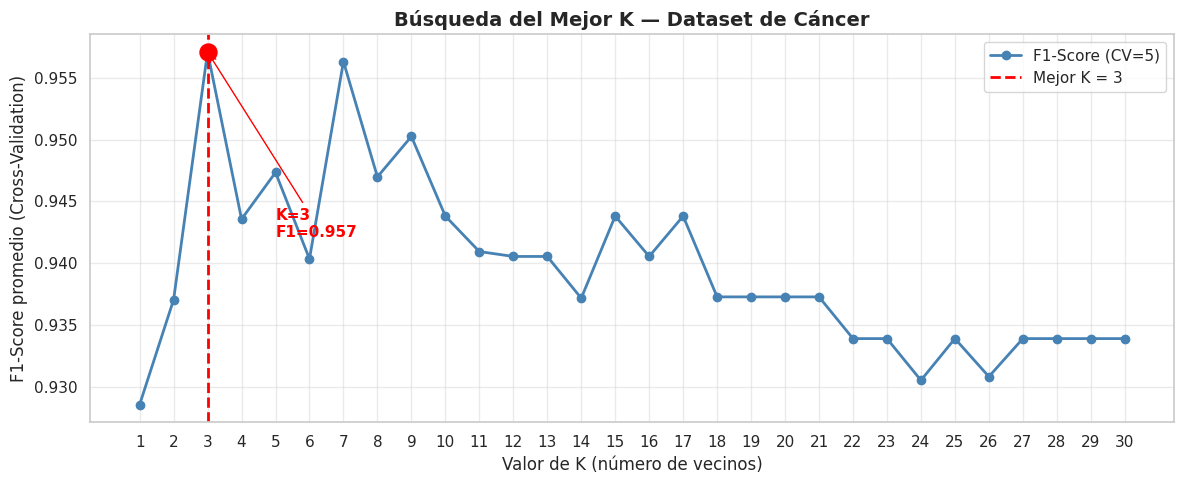

In [ ]:
# GRAFICAMOS cómo varía el rendimiento según K


plt.figure(figsize=(12, 5))
plt.plot(k_values, exactitudes_cv, marker='o', linewidth=2,
         color='steelblue', markersize=6, label='F1-Score (CV=5)')
plt.axvline(x=mejor_k_cancer, color='red', linestyle='--', linewidth=2,
            label=f'Mejor K = {mejor_k_cancer}')
plt.scatter([mejor_k_cancer], [mejor_score], color='red', s=150, zorder=5)
plt.annotate(f'K={mejor_k_cancer}\nF1={mejor_score:.3f}',
             xy=(mejor_k_cancer, mejor_score),
             xytext=(mejor_k_cancer + 2, mejor_score - 0.015),
             fontsize=11, color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))
plt.xlabel('Valor de K (número de vecinos)', fontsize=12)
plt.ylabel('F1-Score promedio (Cross-Validation)', fontsize=12)
plt.title('Búsqueda del Mejor K — Dataset de Cáncer', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(range(1, 31))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('cancer_mejor_k.png', bbox_inches='tight', dpi=150)
plt.show()

## 🤖 BLOQUE D — Entrenamiento y Evaluación del Modelo de Cáncer

In [ ]:
# ENTRENAMIENTO CON EL MEJOR K

# Creamos el modelo con el mejor K encontrado
knn_cancer = KNeighborsClassifier(
    n_neighbors=mejor_k_cancer,  # El mejor K
    metric='euclidean'           # Distancia euclidiana (la distancia recta entre dos puntos)
)

# Entrenamos el modelo con los datos de entrenamiento
# fit = "aprender"
knn_cancer.fit(X_train_c_scaled, y_train_c)

# Hacemos predicciones con los datos de PRUEBA (que el modelo nunca vio)
# predict = "predecir"
y_pred_cancer = knn_cancer.predict(X_test_c_scaled)

print(f" Modelo KNN entrenado con K = {mejor_k_cancer}")
print(f"\n Primeras 10 predicciones vs realidad:")
print(f"   Real:      {list(y_test_c[:10])}  (0=Benigno, 1=Maligno)")
print(f"   Predicho:  {list(y_pred_cancer[:10])}")

 Modelo KNN entrenado con K = 3

 Primeras 10 predicciones vs realidad:
   Real:      [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]  (0=Benigno, 1=Maligno)
   Predicho:  [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]


# MÉTRICAS DE EVALUACIÓN

 En medicina usamos métricas específicas porque los errores no son iguales:

 **Precision**: De todos los que predije como malignos,
   ¿cuántos eran realmente malignos?
   → Alta precisión = pocos falsos alarmas

 **RECUPERACIÓN (Recall / Sensibilidad):** De todos los tumores realmente malignos,
   ¿cuántos detecté?
   → Alta recuperación = no dejar pasar tumores malignos (¡crítico en medicina!)

 **f1-SCORE:** Promedio armónico entre Precisión y Recuperación
   → Balanceo entre los dos. Útil cuando ambos importan.

 **EXACTITUD (Accuracy):** De todos los casos, ¿cuántos acerté en total?

In [ ]:
# MÉTRICAS DE EVALUACIÓN

accuracy    = accuracy_score(y_test_c, y_pred_cancer)
precision   = precision_score(y_test_c, y_pred_cancer)
recall      = recall_score(y_test_c, y_pred_cancer)
f1          = f1_score(y_test_c, y_pred_cancer)

print("="*55)
print(" MÉTRICAS DEL MODELO KNN — DATASET DE CÁNCER")
print("="*55)
print(f"\n Exactitud (Accuracy):        {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"   Precisión (Precision):        {precision:.4f}  ({precision*100:.2f}%)")
print(f"   Recuperación (Recall):        {recall:.4f}  ({recall*100:.2f}%)")
print(f"   F1-Score:                     {f1:.4f}  ({f1*100:.2f}%)")
print("="*55)
print("\n Reporte completo de clasificación:")
print(classification_report(y_test_c, y_pred_cancer,
                             target_names=['Benigno (B)', 'Maligno (M)']))

 MÉTRICAS DEL MODELO KNN — DATASET DE CÁNCER

 Exactitud (Accuracy):        0.9386  (93.86%)
   Precisión (Precision):        0.9730  (97.30%)
   Recuperación (Recall):        0.8571  (85.71%)
   F1-Score:                     0.9114  (91.14%)

 Reporte completo de clasificación:
              precision    recall  f1-score   support

 Benigno (B)       0.92      0.99      0.95        72
 Maligno (M)       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



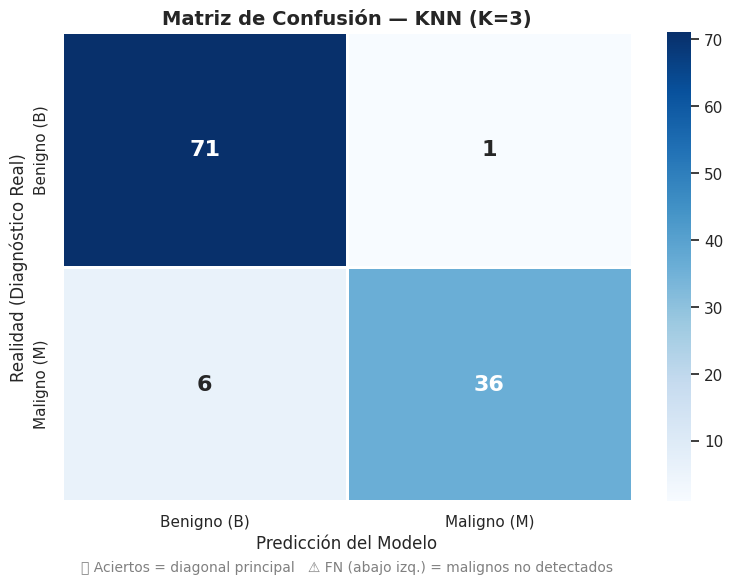


 Interpretación detallada:
    Benignos correctamente detectados:  71
    Malignos correctamente detectados:  36
    Falsos positivos (B predicho M):    1 → pacientes con alarma innecesaria
    Falsos negativos (M predicho B):   6 → malignos no detectados (RIESGO)


In [ ]:
# MATRIZ DE CONFUSIÓN

# La matriz de confusión muestra los 4 tipos de resultados posibles:

#                  B         M
# REAL    B  [ TP (✅) | FP (❌) ]  ← Benignos reales
#         M  [ FN (⚠️) | TN (✅) ]  ← Malignos reales

# TP (True Positive):  Dijo Benigno, era Benigno   ✅
# TN (True Negative):  Dijo Maligno, era Maligno   ✅
# FP (False Positive): Dijo Maligno, era Benigno   ❌ (falsa alarma)
# FN (False Negative): Dijo Benigno, era Maligno   ⚠️ (MUY PELIGROSO en medicina)

cm = confusion_matrix(y_test_c, y_pred_cancer)

fig, ax = plt.subplots(figsize=(8, 6))

# Dibujamos la matriz con colores
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Benigno (B)', 'Maligno (M)'],
            yticklabels=['Benigno (B)', 'Maligno (M)'],
            linewidths=2,
            linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'},
            ax=ax)

ax.set_title(f'Matriz de Confusión — KNN (K={mejor_k_cancer})', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicción del Modelo', fontsize=12)
ax.set_ylabel('Realidad (Diagnóstico Real)', fontsize=12)

# Añadimos etiquetas explicativas
ax.text(0.5, -0.15, '✅ Aciertos = diagonal principal   ⚠️ FN (abajo izq.) = malignos no detectados',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('cancer_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# Interpretamos los resultados

tn, fp, fn, tp = cm.ravel()
print("\n Interpretación detallada:")
print(f"    Benignos correctamente detectados:  {tn}")
print(f"    Malignos correctamente detectados:  {tp}")
print(f"    Falsos positivos (B predicho M):    {fp} → pacientes con alarma innecesaria")
print(f"    Falsos negativos (M predicho B):   {fn} → malignos no detectados (RIESGO)")

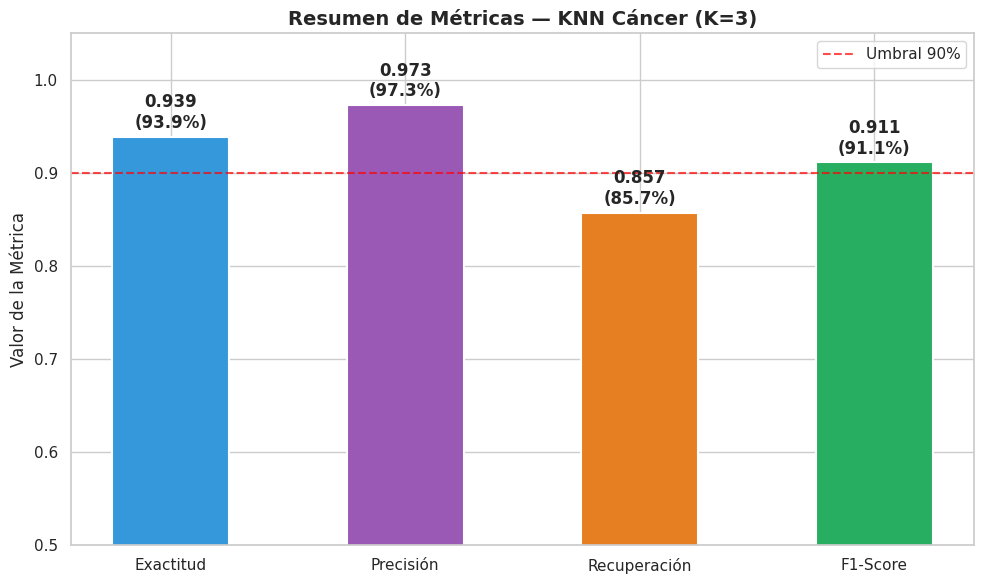

In [ ]:
# GRÁFICA RESUMEN DE MÉTRICAS

metricas = ['Exactitud', 'Precisión', 'Recuperación', 'F1-Score']
valores = [accuracy, precision, recall, f1]
colores_m = ['#3498db', '#9b59b6', '#e67e22', '#27ae60']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metricas, valores, color=colores_m, edgecolor='white', linewidth=1.5, width=0.5)

# Línea de referencia en 90%
ax.axhline(y=0.9, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral 90%')

# Etiquetas sobre las barras
for bar, valor in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{valor:.3f}\n({valor*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0.5, 1.05)
ax.set_title(f'Resumen de Métricas — KNN Cáncer (K={mejor_k_cancer})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Valor de la Métrica', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('cancer_metricas.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# INTERPRETACIÓN Y CONCLUSIÓN DEL CASO 1

print(" CONCLUSIÓN — CASO 1: CLASIFICACIÓN DE TUMORES")
print(f"""
 RESUMEN DEL MODELO:
   • Algoritmo:     KNN con K = {mejor_k_cancer} vecinos
   • Dataset:       569 pacientes (357 B, 212 M)
   • Split:         80% entrenamiento, 20% prueba

 RESULTADOS:
   • Exactitud:     {accuracy*100:.1f}% → De 100 tumores, acierta ~{accuracy*100:.0f}
   • Precisión:     {precision*100:.1f}% → Cuando dice 'maligno', acierta {precision*100:.0f}% de las veces
   • Recuperación:  {recall*100:.1f}% → Detecta {recall*100:.0f}% de todos los tumores malignos
   • F1-Score:      {f1*100:.1f}% → Balance entre Precisión y Recuperación

 INTERPRETACIÓN MÉDICA:
   En contexto médico, la RECUPERACIÓN es la métrica más importante.
   Un Recall de {recall*100:.1f}% significa que de cada 100 tumores malignos
   reales, el modelo detecta aproximadamente {recall*100:.0f}.
   Los {fn} casos no detectados (Falsos Negativos) representan el
   riesgo principal del modelo.

 CONCLUSIÓN:
   El modelo KNN muestra un rendimiento {'EXCELENTE' if f1 > 0.93 else 'MUY BUENO' if f1 > 0.88 else 'BUENO'}
   para una tarea médica de clasificación binaria.
   Es una herramienta útil de apoyo diagnóstico, aunque
   nunca debe reemplazar el criterio médico profesional.
""")

 CONCLUSIÓN — CASO 1: CLASIFICACIÓN DE TUMORES

 RESUMEN DEL MODELO:
   • Algoritmo:     KNN con K = 3 vecinos
   • Dataset:       569 pacientes (357 B, 212 M)
   • Split:         80% entrenamiento, 20% prueba

 RESULTADOS:
   • Exactitud:     93.9% → De 100 tumores, acierta ~94
   • Precisión:     97.3% → Cuando dice 'maligno', acierta 97% de las veces
   • Recuperación:  85.7% → Detecta 86% de todos los tumores malignos
   • F1-Score:      91.1% → Balance entre Precisión y Recuperación

 INTERPRETACIÓN MÉDICA:
   En contexto médico, la RECUPERACIÓN es la métrica más importante.
   Un Recall de 85.7% significa que de cada 100 tumores malignos
   reales, el modelo detecta aproximadamente 86.
   Los 6 casos no detectados (Falsos Negativos) representan el
   riesgo principal del modelo.

 CONCLUSIÓN:
   El modelo KNN muestra un rendimiento MUY BUENO
   para una tarea médica de clasificación binaria.
   Es una herramienta útil de apoyo diagnóstico, aunque
   nunca debe reemplazar el crite

# Challenge: Wine Quality data

## Objetivo:
Determinar la calidad del vino con base en su características

1. Aplicar el algoritmo de KNN a Wine Quality Data que se encuentra dentro del siguiente link 👇🏼

> https://archive.ics.uci.edu/ml/datasets/Wine+Quality

2. Evaluar el rendimiento del modelo

# 🍷 CASO 2: CLASIFICACIÓN DE CALIDAD DEL VINO
## Dataset: Wine Quality Data (UCI Repository)

**¿Cuál es el problema?**
Un enólogo (experto en vinos) evalúa cada vino del 1 al 10 según su calidad.
¿Podemos predecir esa calidad basándonos en las propiedades químicas del vino?

**¿Por qué es más difícil que el caso anterior?**
- En cáncer: 2 clases (B o M)
- En vino: múltiples clases (3, 4, 5, 6, 7, 8, 9) → **clasificación multiclase**

**Estrategia:** Combinaremos vino tinto y

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cargar desde archivos CSV subidos a Google Drive

import pandas as pd

ruta_colab = '/content/MyDrive/'
df_red   = pd.read_csv('/content/drive/MyDrive/winequality-red.csv',  sep=';')
df_white = pd.read_csv('/content/drive/MyDrive/winequality-white.csv',sep=';')

# Añadimos una columna para identificar el tipo de vino
# 0 = tinto, 1 = blanco

df_red['wine_type']   = 0  # Tinto
df_white['wine_type'] = 1  # Blanco

# Combinamos ambos datasets en uno solo

df_wine = pd.concat([df_red, df_white], ignore_index=True)

print("="*55)
print(" EXPLORACIÓN DEL DATASET DE VINO")
print("="*55)
print(f"\n Dimensiones del dataset combinado:")
print(f"   • Vino tinto:  {len(df_red):>5} muestras")
print(f"   • Vino blanco: {len(df_white):>5} muestras")
print(f"   • Total:       {len(df_wine):>5} muestras")
print(f"   • Variables:   {df_wine.shape[1]} columnas")

print(f"\n Distribución de calidad:")
conteo_calidad = df_wine['quality'].value_counts().sort_index()
for calidad, cantidad in conteo_calidad.items():
    barra = '█' * int(cantidad/20)
    print(f"   Calidad {calidad}: {cantidad:>4} vinos  {barra}")

print(f"\n Primeras 10 filas:")
df_wine.head(10)

 EXPLORACIÓN DEL DATASET DE VINO

 Dimensiones del dataset combinado:
   • Vino tinto:   1599 muestras
   • Vino blanco:  4898 muestras
   • Total:        6497 muestras
   • Variables:   13 columnas

 Distribución de calidad:
   Calidad 3:   30 vinos  █
   Calidad 4:  216 vinos  ██████████
   Calidad 5: 2138 vinos  ██████████████████████████████████████████████████████████████████████████████████████████████████████████
   Calidad 6: 2836 vinos  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   Calidad 7: 1079 vinos  █████████████████████████████████████████████████████
   Calidad 8:  193 vinos  █████████
   Calidad 9:    5 vinos  

 Primeras 10 filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,0
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,0
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,0


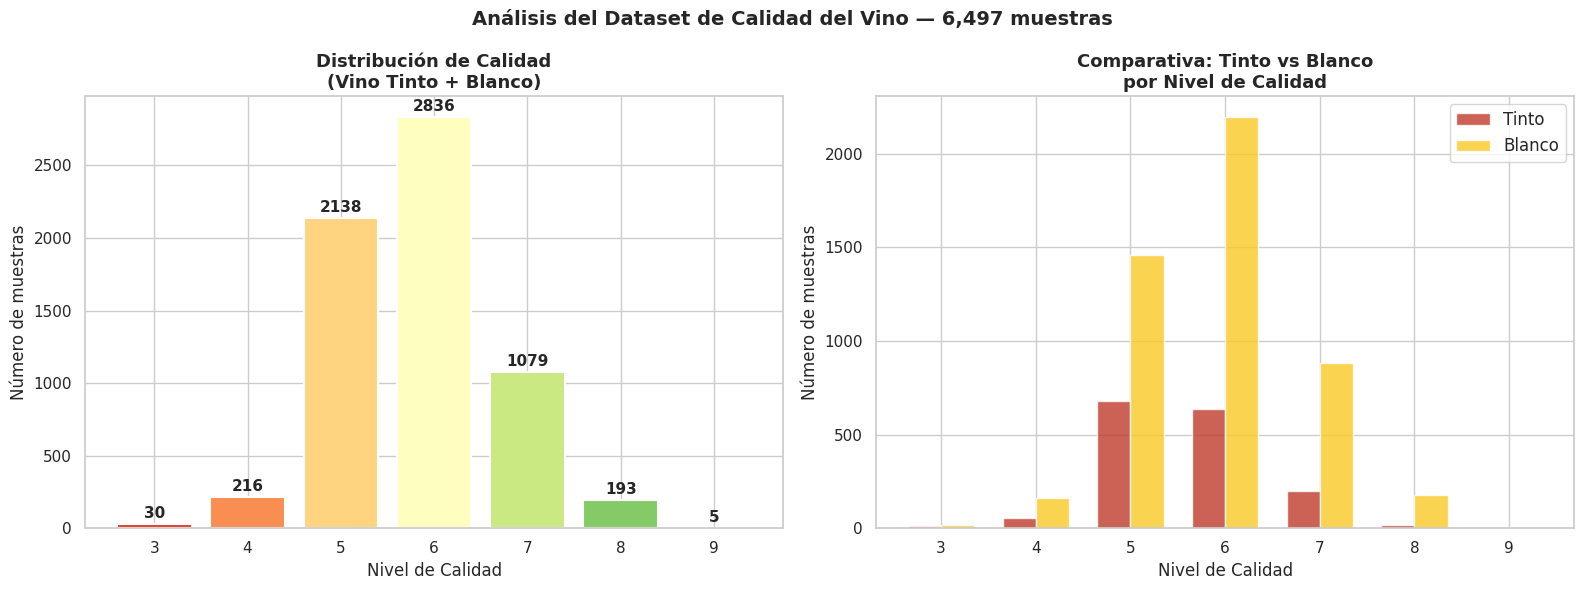


 Observación importante:
   La mayoría de vinos tienen calidad 5 y 6.
   Hay muy pocos con calidad 3, 4, 8 y 9 (clases minoritarias).
   Esto crea un desbalance que puede afectar el rendimiento del modelo.


In [ ]:
# VISUALIZACIÓN 3: Distribución de calidad del vino

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Paleta de colores por calidad

paleta = sns.color_palette("RdYlGn", n_colors=7)

# Gráfica 1: Dataset combinado

calidades = sorted(df_wine['quality'].unique())
conteos = [df_wine[df_wine['quality'] == c].shape[0] for c in calidades]
bars = axes[0].bar(calidades, conteos, color=paleta, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, conteos):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('Distribución de Calidad\n(Vino Tinto + Blanco)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nivel de Calidad', fontsize=12)
axes[0].set_ylabel('Número de muestras', fontsize=12)
axes[0].set_xticks(calidades)

# Gráfica 2: Comparativa tinto vs blanco

calidades_red = df_red['quality'].value_counts().sort_index()
calidades_whi = df_white['quality'].value_counts().sort_index()

x_pos = np.array(sorted(set(list(calidades_red.index) + list(calidades_whi.index))))
width = 0.35

red_vals = [calidades_red.get(q, 0) for q in x_pos]
whi_vals = [calidades_whi.get(q, 0) for q in x_pos]

axes[1].bar(x_pos - width/2, red_vals, width, label='Tinto', color='#c0392b', alpha=0.8)
axes[1].bar(x_pos + width/2, whi_vals, width, label='Blanco', color='#f9ca24', alpha=0.8)

axes[1].set_title('Comparativa: Tinto vs Blanco\npor Nivel de Calidad', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nivel de Calidad', fontsize=12)
axes[1].set_ylabel('Número de muestras', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].legend(fontsize=12)

plt.suptitle('Análisis del Dataset de Calidad del Vino — 6,497 muestras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vino_distribucion.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n Observación importante:")
print("   La mayoría de vinos tienen calidad 5 y 6.")
print("   Hay muy pocos con calidad 3, 4, 8 y 9 (clases minoritarias).")
print("   Esto crea un desbalance que puede afectar el rendimiento del modelo.")


# ESTRATEGIA: Agrupar calidades en 3 categorías

El problema con tener 7 clases (3 al 9) es que algunas tienen
muy pocas muestras (solo 5 vinos de calidad 3 en la data combinada).
Esto hace muy difícil que el modelo aprenda esa categoría.

 Solución práctica en análisis de vinos: agrupar en 3 niveles
 - Baja calidad:  3, 4, 5
 - Media calidad: 6
 - Alta calidad:  7, 8, 9

Esto también tiene sentido de negocio:
¿El vino es para venta económica, estándar o premium?


In [ ]:

def categorizar_calidad(q):
    """Convierte puntuación numérica en categoría de calidad"""
    if q <= 5:
        return 0   # 'Baja'
    elif q == 6:
        return 1   # 'Media'
    else:
        return 2   # 'Alta'

# Aplicamos la función a cada valor de calidad

df_wine['quality_cat'] = df_wine['quality'].apply(categorizar_calidad)

# Verificamos la distribución nueva

nombres_categorias = {0: 'Baja (3-5)', 1: 'Media (6)', 2: 'Alta (7-9)'}
conteo_cat = df_wine['quality_cat'].value_counts().sort_index()

print(" Nueva distribución por categorías:")
for cat, total in conteo_cat.items():
    print(f"   {nombres_categorias[cat]:>15}: {total:>4} vinos ({total/len(df_wine)*100:.1f}%)")

print("\n Agrupación realizada. Ahora tenemos 3 clases más balanceadas.")

 Nueva distribución por categorías:
        Baja (3-5): 2384 vinos (36.7%)
         Media (6): 2836 vinos (43.7%)
        Alta (7-9): 1277 vinos (19.7%)

 Agrupación realizada. Ahora tenemos 3 clases más balanceadas.


##  BLOQUE A — Preparación de Datos del Vino

In [ ]:
# PREPARACIÓN DE X e y para el vino


# X = todas las características químicas del vino (y el tipo: tinto/blanco)
# Eliminamos las columnas de calidad (las que queremos predecir)
X_wine = df_wine.drop(columns=['quality', 'quality_cat'])

# y = la categoría de calidad (0=Baja, 1=Media, 2=Alta)
y_wine = df_wine['quality_cat']

print(" Dimensiones:")
print(f"   X (características): {X_wine.shape}")
print(f"   y (objetivo):        {y_wine.shape}")
print(f"\n   Características disponibles:")
for i, col in enumerate(X_wine.columns, 1):
    print(f"   {i:>2}. {col}")

# División en entrenamiento y prueba


X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine,
    y_wine,
    test_size=0.20,
    random_state=42,
    stratify=y_wine  # Mantiene proporciones de cada categoría
)

# Normalización
scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled  = scaler_w.transform(X_test_w)

print(f"\n  División:")
print(f"   Entrenamiento: {len(X_train_w)} muestras")
print(f"   Prueba:        {len(X_test_w)} muestras")
print(f"\n Datos normalizados y listos para entrenamiento")

 Dimensiones:
   X (características): (6497, 12)
   y (objetivo):        (6497,)

   Características disponibles:
    1. fixed acidity
    2. volatile acidity
    3. citric acid
    4. residual sugar
    5. chlorides
    6. free sulfur dioxide
    7. total sulfur dioxide
    8. density
    9. pH
   10. sulphates
   11. alcohol
   12. wine_type

  División:
   Entrenamiento: 5197 muestras
   Prueba:        1300 muestras

 Datos normalizados y listos para entrenamiento


##  BLOQUE B — Búsqueda del Mejor K para el Vino

 Buscando el mejor K para el dataset de vino...
   (Esto puede tardar unos segundos por el tamaño del dataset)

 Mejor K encontrado: K = 1
   F1-Score ponderado: 0.6511 (65.11%)


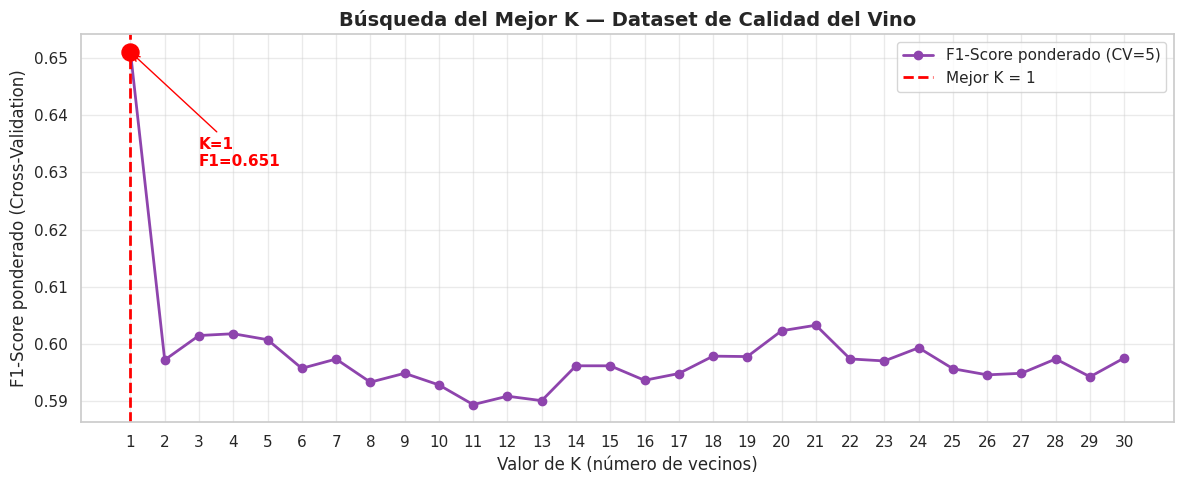

In [ ]:
# BÚSQUEDA DEL MEJOR K PARA EL VINO
# Usamos 'weighted' en F1 para manejar el desbalance entre clases

k_values = range(1, 31)
exactitudes_cv_wine = []

print(" Buscando el mejor K para el dataset de vino...")
print("   (Esto puede tardar unos segundos por el tamaño del dataset)")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # 'weighted' pondera el F1 por el número de muestras de cada clase
    # Importante cuando hay clases con más o menos muestras

    scores = cross_val_score(knn, X_train_w_scaled, y_train_w,
                             cv=5, scoring='f1_weighted')
    exactitudes_cv_wine.append(scores.mean())

mejor_k_wine = k_values[np.argmax(exactitudes_cv_wine)]
mejor_score_wine = max(exactitudes_cv_wine)

print(f"\n Mejor K encontrado: K = {mejor_k_wine}")
print(f"   F1-Score ponderado: {mejor_score_wine:.4f} ({mejor_score_wine*100:.2f}%)")

# Graficamos

plt.figure(figsize=(12, 5))
plt.plot(k_values, exactitudes_cv_wine, marker='o', linewidth=2,
         color='#8e44ad', markersize=6, label='F1-Score ponderado (CV=5)')
plt.axvline(x=mejor_k_wine, color='red', linestyle='--', linewidth=2,
            label=f'Mejor K = {mejor_k_wine}')
plt.scatter([mejor_k_wine], [mejor_score_wine], color='red', s=150, zorder=5)
plt.annotate(f'K={mejor_k_wine}\nF1={mejor_score_wine:.3f}',
             xy=(mejor_k_wine, mejor_score_wine),
             xytext=(mejor_k_wine + 2, mejor_score_wine - 0.02),
             fontsize=11, color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))
plt.xlabel('Valor de K (número de vecinos)', fontsize=12)
plt.ylabel('F1-Score ponderado (Cross-Validation)', fontsize=12)
plt.title('Búsqueda del Mejor K — Dataset de Calidad del Vino', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(range(1, 31))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('vino_mejor_k.png', bbox_inches='tight', dpi=150)
plt.show()

# BLOQUE C — Entrenamiento y Evaluación del Modelo de Vino

In [ ]:
# ENTRENAMIENTO CON EL MEJOR K


knn_wine = KNeighborsClassifier(
    n_neighbors=mejor_k_wine,
    metric='euclidean'
)

knn_wine.fit(X_train_w_scaled, y_train_w)
y_pred_wine = knn_wine.predict(X_test_w_scaled)

print(f" Modelo KNN entrenado con K = {mejor_k_wine}")


# MÉTRICAS PARA CLASIFICACIÓN MULTICLASE
# En clasificación multiclase usamos 'weighted' para ponderar
# cada clase según su frecuencia en el dataset


accuracy_w   = accuracy_score(y_test_w, y_pred_wine)
precision_w  = precision_score(y_test_w, y_pred_wine, average='weighted')
recall_w     = recall_score(y_test_w, y_pred_wine, average='weighted')
f1_w         = f1_score(y_test_w, y_pred_wine, average='weighted')

print("\n" + "="*55)
print(" MÉTRICAS DEL MODELO KNN — CALIDAD DEL VINO")
print("="*55)
print(f"\n  Exactitud (Accuracy):        {accuracy_w:.4f}  ({accuracy_w*100:.2f}%)")
print(f"   Precisión (Precision):        {precision_w:.4f}  ({precision_w*100:.2f}%)")
print(f"   Recuperación (Recall):        {recall_w:.4f}  ({recall_w*100:.2f}%)")
print(f"   F1-Score (ponderado):         {f1_w:.4f}  ({f1_w*100:.2f}%)")
print("="*55)

print("\n Reporte detallado por categoría:")
print(classification_report(y_test_w, y_pred_wine,
                             target_names=['Baja (3-5)', 'Media (6)', 'Alta (7-9)']))

 Modelo KNN entrenado con K = 1

 MÉTRICAS DEL MODELO KNN — CALIDAD DEL VINO

  Exactitud (Accuracy):        0.6469  (64.69%)
   Precisión (Precision):        0.6490  (64.90%)
   Recuperación (Recall):        0.6469  (64.69%)
   F1-Score (ponderado):         0.6476  (64.76%)

 Reporte detallado por categoría:
              precision    recall  f1-score   support

  Baja (3-5)       0.71      0.66      0.68       477
   Media (6)       0.62      0.63      0.63       567
  Alta (7-9)       0.60      0.65      0.63       256

    accuracy                           0.65      1300
   macro avg       0.64      0.65      0.65      1300
weighted avg       0.65      0.65      0.65      1300



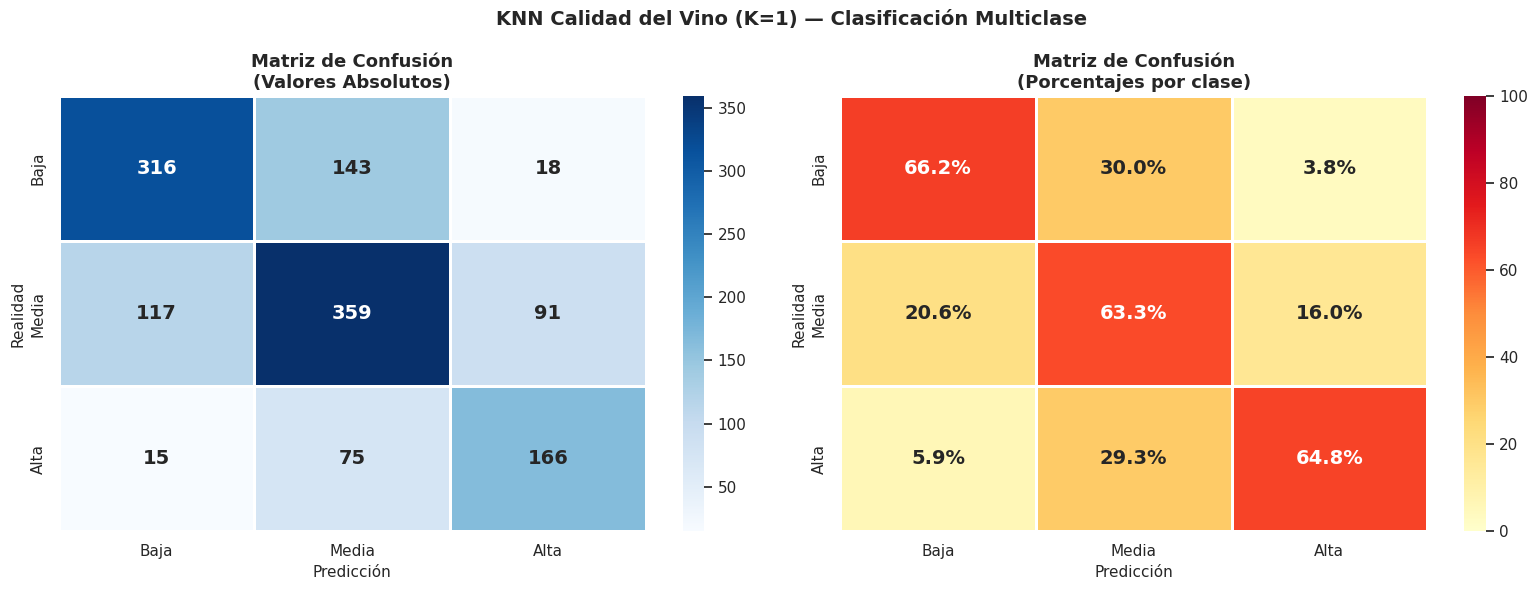


 Interpretación:
   Baja  → predice Baja  correctamente: 66.2%
   Media → predice Media correctamente: 63.3%
   Alta  → predice Alta  correctamente: 64.8%


In [ ]:
# MATRIZ DE CONFUSIÓN PARA EL VINO

# Ahora tenemos 3x3 porque hay 3 categorías


cm_wine = confusion_matrix(y_test_w, y_pred_wine)

# Calculamos porcentajes por fila (de cada clase real, ¿qué % predijo correctamente?)
cm_pct = cm_wine.astype('float') / cm_wine.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz con valores absolutos

sns.heatmap(cm_wine, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja', 'Media', 'Alta'],
            yticklabels=['Baja', 'Media', 'Alta'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'}, ax=axes[0])
axes[0].set_title('Matriz de Confusión\n(Valores Absolutos)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=11)
axes[0].set_ylabel('Realidad', fontsize=11)

# Matriz con porcentajes
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=['Baja', 'Media', 'Alta'],
            yticklabels=['Baja', 'Media', 'Alta'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'}, ax=axes[1],
            vmin=0, vmax=100)
axes[1].set_title('Matriz de Confusión\n(Porcentajes por clase)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=11)
axes[1].set_ylabel('Realidad', fontsize=11)

# Añadimos el símbolo % a cada celda de la segunda matriz
for text in axes[1].texts:
    text.set_text(text.get_text() + '%')

plt.suptitle(f'KNN Calidad del Vino (K={mejor_k_wine}) — Clasificación Multiclase',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vino_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# Interpretamos
print("\n Interpretación:")
print(f"   Baja  → predice Baja  correctamente: {cm_pct[0,0]:.1f}%")
print(f"   Media → predice Media correctamente: {cm_pct[1,1]:.1f}%")
print(f"   Alta  → predice Alta  correctamente: {cm_pct[2,2]:.1f}%")

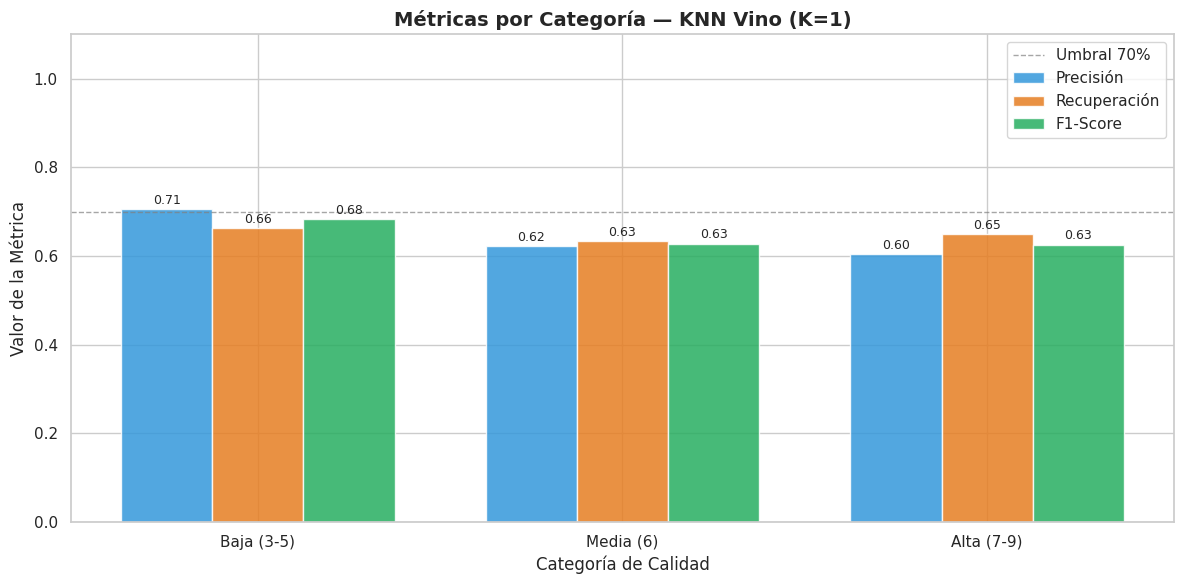

In [ ]:
# VISUALIZACIÓN: Métricas por categoría


from sklearn.metrics import precision_recall_fscore_support

# Calculamos métricas para cada clase individualmente
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
    y_test_w, y_pred_wine, average=None
)

categorias = ['Baja (3-5)', 'Media (6)', 'Alta (7-9)']
x = np.arange(len(categorias))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, prec_c, width, label='Precisión',    color='#3498db', alpha=0.85)
bars2 = ax.bar(x,         rec_c,  width, label='Recuperación', color='#e67e22', alpha=0.85)
bars3 = ax.bar(x + width, f1_c,   width, label='F1-Score',     color='#27ae60', alpha=0.85)

# Etiquetas sobre las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.axhline(y=0.7, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Umbral 70%')
ax.set_xlabel('Categoría de Calidad', fontsize=12)
ax.set_ylabel('Valor de la Métrica', fontsize=12)
ax.set_title(f'Métricas por Categoría — KNN Vino (K={mejor_k_wine})', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('vino_metricas_por_clase.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# INTERPRETACIÓN Y CONCLUSIÓN DEL CASO 2


print("="*60)
print(" CONCLUSIÓN — CASO 2: CALIDAD DEL VINO")
print("="*60)
print(f"""
 RESUMEN DEL MODELO:
   • Algoritmo:     KNN con K = {mejor_k_wine} vecinos
   • Dataset:       6,497 vinos (tinto + blanco)
   • Clases:        3 categorías (Baja, Media, Alta)
   • Split:         80% entrenamiento, 20% prueba

 RESULTADOS GLOBALES:
   • Exactitud:     {accuracy_w*100:.1f}%
   • Precisión:     {precision_w*100:.1f}% (promedio ponderado)
   • Recuperación:  {recall_w*100:.1f}% (promedio ponderado)
   • F1-Score:      {f1_w*100:.1f}% (promedio ponderado)

 RESULTADOS POR CATEGORÍA:
   • Baja  (3-5): F1 = {f1_c[0]*100:.1f}%  → {':(' if f1_c[0] < 0.6 else '🆗' if f1_c[0] < 0.75 else '✅'}
   • Media (6):   F1 = {f1_c[1]*100:.1f}%  → {':(' if f1_c[1] < 0.6 else '🆗' if f1_c[1] < 0.75 else '✅'}
   • Alta  (7-9): F1 = {f1_c[2]*100:.1f}%  → {':(' if f1_c[2] < 0.6 else '🆗' if f1_c[2] < 0.75 else '✅'}

 INTERPRETACIÓN DE NEGOCIO:
   En la industria vinícola, clasificar correctamente el vino
   es clave para fijar precios y estrategias de venta.

   • Si el modelo confunde 'Baja' con 'Media' → se podría
     vender vino de menor calidad a mayor precio (riesgo de marca)
   • Si confunde 'Alta' con 'Media' → se perdería valor
     al vender vinos premium a precio estándar

 CONCLUSIÓN:
   La clasificación multiclase es más difícil que la binaria.
   KNN logra un desempeño aceptable, especialmente en la categoría
   'Media' que es la más frecuente.
   Para mejorar, se podría considerar:
   → Más datos de vinos de calidad baja y alta
   → Probar otros algoritmos (Random Forest, XGBoost)
   → Ajustar los rangos de las categorías
""")

 CONCLUSIÓN — CASO 2: CALIDAD DEL VINO

 RESUMEN DEL MODELO:
   • Algoritmo:     KNN con K = 1 vecinos
   • Dataset:       6,497 vinos (tinto + blanco)
   • Clases:        3 categorías (Baja, Media, Alta)
   • Split:         80% entrenamiento, 20% prueba

 RESULTADOS GLOBALES:
   • Exactitud:     64.7%
   • Precisión:     64.9% (promedio ponderado)
   • Recuperación:  64.7% (promedio ponderado)
   • F1-Score:      64.8% (promedio ponderado)

 RESULTADOS POR CATEGORÍA:
   • Baja  (3-5): F1 = 68.3%  → 🆗
   • Media (6):   F1 = 62.8%  → 🆗
   • Alta  (7-9): F1 = 62.5%  → 🆗

 INTERPRETACIÓN DE NEGOCIO:
   En la industria vinícola, clasificar correctamente el vino
   es clave para fijar precios y estrategias de venta.

   • Si el modelo confunde 'Baja' con 'Media' → se podría
     vender vino de menor calidad a mayor precio (riesgo de marca)
   • Si confunde 'Alta' con 'Media' → se perdería valor
     al vender vinos premium a precio estándar

 CONCLUSIÓN:
   La clasificación multiclase es má

# 📊 BLOQUE D — Comparativa Final: Cáncer vs Vino

Comparamos ambos modelos para entender por qué uno funciona mejor que el otro.

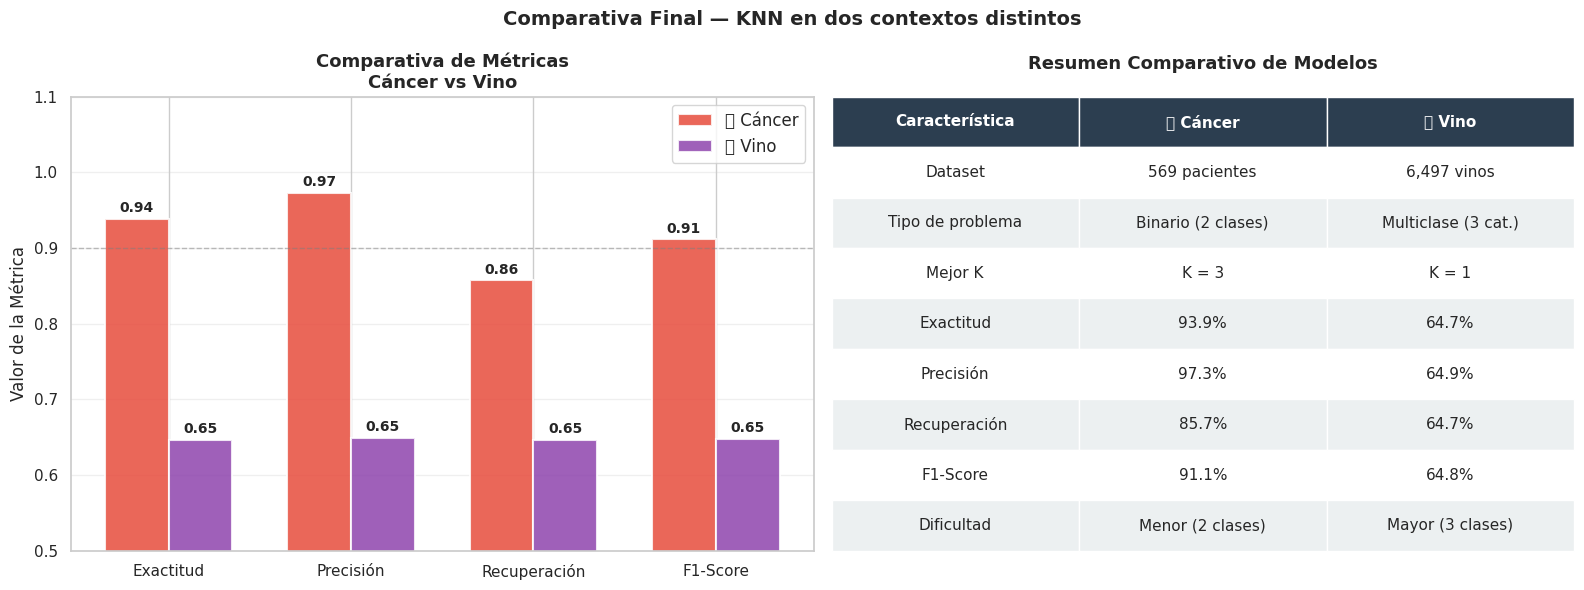

In [ ]:
# TABLA COMPARATIVA FINAL

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Datos para comparación

metricas_nombres = ['Exactitud', 'Precisión', 'Recuperación', 'F1-Score']
valores_cancer = [accuracy, precision, recall, f1]
valores_vino   = [accuracy_w, precision_w, recall_w, f1_w]

x = np.arange(len(metricas_nombres))
width = 0.35

# Gráfica de barras comparativa

bars1 = axes[0].bar(x - width/2, valores_cancer, width, label=' Cáncer',
                    color='#e74c3c', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = axes[0].bar(x + width/2, valores_vino, width, label=' Vino',
                    color='#8e44ad', alpha=0.85, edgecolor='white', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_ylim(0.5, 1.1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas_nombres, fontsize=11)
axes[0].set_ylabel('Valor de la Métrica', fontsize=12)
axes[0].set_title('Comparativa de Métricas\nCáncer vs Vino', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].axhline(y=0.9, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].grid(True, alpha=0.3, axis='y')

# Tabla resumen

axes[1].axis('off')
tabla_data = [
    ['Característica', ' Cáncer', ' Vino'],
    ['Dataset', '569 pacientes', '6,497 vinos'],
    ['Tipo de problema', 'Binario (2 clases)', 'Multiclase (3 cat.)'],
    [f'Mejor K', f'K = {mejor_k_cancer}', f'K = {mejor_k_wine}'],
    ['Exactitud', f'{accuracy*100:.1f}%', f'{accuracy_w*100:.1f}%'],
    ['Precisión', f'{precision*100:.1f}%', f'{precision_w*100:.1f}%'],
    ['Recuperación', f'{recall*100:.1f}%', f'{recall_w*100:.1f}%'],
    ['F1-Score', f'{f1*100:.1f}%', f'{f1_w*100:.1f}%'],
    ['Dificultad', 'Menor (2 clases)', 'Mayor (3 clases)'],
]

tabla = axes[1].table(
    cellText=tabla_data[1:],
    colLabels=tabla_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)

# Colorear encabezado
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    cell.set_edgecolor('white')

axes[1].set_title('Resumen Comparativo de Modelos', fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Comparativa Final — KNN en dos contextos distintos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_final.png', bbox_inches='tight', dpi=150)
plt.show()

In [80]:
# REFLEXIÓN FINAL


print("="*65)
print(" REFLEXIÓN FINAL — EVALUACIÓN DEL RENDIMIENTO DE LOS MODELOS")
print("="*65)
print("""


1️  PREPROCESAMIENTO ES CLAVE
    KNN es uno de los algoritmos MÁS sensibles a la escala
    de los datos. Sin normalizar, los resultados serían mucho peores.
    → StandardScaler fue indispensable en ambos casos.

2️  EL NÚMERO DE CLASES IMPACTA EL RENDIMIENTO
    El modelo de cáncer (2 clases) obtuvo métricas superiores
    al de vino (3 clases). Con más clases, el problema es
    más complejo y el modelo tiene más oportunidades de equivocarse.

3️  LA MÉTRICA IMPORTA SEGÚN EL CONTEXTO
    • En medicina: Recall (Recuperación) es prioritario.
      Mejor un falso positivo que no detectar un cáncer.
    • En negocio (vinos): F1-Score ponderado da una visión
      más equilibrada entre todas las categorías.

4️  EL DESBALANCE AFECTA EL MODELO
    En el vino, las clases 'Baja' y 'Alta' tienen menos muestras
    que 'Media'. El modelo tiende a predecir más 'Media' porque
    aprendió que es la respuesta más frecuente.

5️  KNN ES UN ALGORITMO SIMPLE PERO EFECTIVO
    No tiene ecuaciones complejas ni pesos que aprender.
    Solo busca los vecinos más parecidos y vota.
    Es un excelente punto de partida antes de algoritmos más complejos.

""")

 REFLEXIÓN FINAL — EVALUACIÓN DEL RENDIMIENTO DE LOS MODELOS



1️  PREPROCESAMIENTO ES CLAVE
    KNN es uno de los algoritmos MÁS sensibles a la escala
    de los datos. Sin normalizar, los resultados serían mucho peores.
    → StandardScaler fue indispensable en ambos casos.

2️  EL NÚMERO DE CLASES IMPACTA EL RENDIMIENTO
    El modelo de cáncer (2 clases) obtuvo métricas superiores
    al de vino (3 clases). Con más clases, el problema es
    más complejo y el modelo tiene más oportunidades de equivocarse.

3️  LA MÉTRICA IMPORTA SEGÚN EL CONTEXTO
    • En medicina: Recall (Recuperación) es prioritario.
      Mejor un falso positivo que no detectar un cáncer.
    • En negocio (vinos): F1-Score ponderado da una visión
      más equilibrada entre todas las categorías.

4️  EL DESBALANCE AFECTA EL MODELO
    En el vino, las clases 'Baja' y 'Alta' tienen menos muestras
    que 'Media'. El modelo tiende a predecir más 'Media' porque
    aprendió que es la respuesta más frecuente.

5️  KN